## To Do:
- Data Import
- Data Preprocessing
- Data Exploration
- Data Visualization
- Explicit Sentiment Analysis
- Implicit Sentiment Analysis
- Comparison

# Thesis

## 1. Data Exploration

### 1.1 Library Import

In [434]:
# Install all necessary libraries

# Data exploration
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data Cleaning
import string
import re
import nltk
import wordcloud

# Model Preparation
import sklearn
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.preprocessing import OneHotEncoder


# Base Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Explicit Sentiment Analysis
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset
import torch
from transformers import AdamW, get_linear_schedule_with_warmup
from tqdm import tqdm

# Implicit Sentiment Analysis

import warnings
warnings.filterwarnings("ignore")

### 1.2. Data Import

In [435]:
# Data Import
train = pd.read_csv('data/train.csv', index_col='id')
test = pd.read_csv('data/test.csv', index_col='id')


The data we are working with contains a train and a test dataset. Both datasets contain the following columns: `id`, `keyword`, `location`, `text` and `target`. The `id` column is a unique identifier for each tweet, the `keyword` column contains the keyword of a tweet, the `location` column contains the location of the tweet, the `text` column contains the tweet itself and the `target` column contains the target of the tweet. The target is a binary value, where 1 indicates that the tweet is about a real disaster and 0 indicates that the tweet is not about a real disaster.

### 1.3. Data Exploration

In [436]:
# Inspecting the train data
print(train.shape)
train.head()

(7613, 4)


,keyword,location,text,target
id,,,,
1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [437]:
# Inspecting the test data
print(test.shape)
test.head()

(3263, 3)


,keyword,location,text
id,,,
0,NaN,NaN,Just happened a terrible car crash
2,NaN,NaN,"Heard about #earthquake is different cities, s..."
3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


Let us now try and visualise the training data for potential anomalies, null values and other such issues. We will also try to understand the distribution of the data.

In [438]:
# Checking for missing values
train.isnull().sum()



keyword       61
location    2533
text           0
target         0
dtype: int64

As we can see, there are some missing values in the data, let us now plot this in order to grasp its distribution.

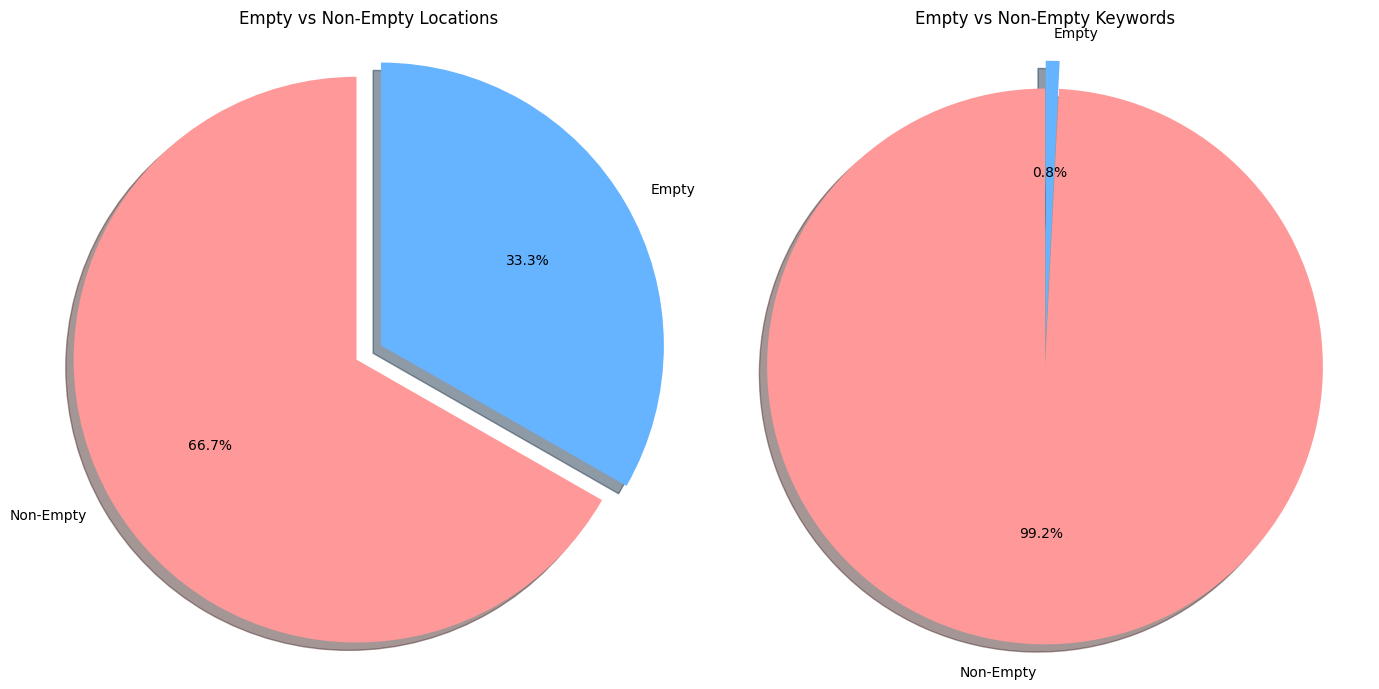

In [439]:
location_counts = train['location'].isnull().value_counts()
keyword_counts = train['keyword'].isnull().value_counts()

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 7))  # figsize to ensure enough space for both plots

# Colors and explode settings for better visualization
colors_location = ['#ff9999','#66b3ff']
explode_location = (0.1, 0) 

# Pie chart for locations
ax[0].pie(location_counts, explode=explode_location, labels=['Non-Empty', 'Empty'], colors=colors_location, autopct='%1.1f%%', startangle=90, shadow=True)
ax[0].set_title('Empty vs Non-Empty Locations')
ax[0].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Colors and explode settings for better visualization
colors_keyword = ['#ff9999','#66b3ff']
explode_keyword = (0.1, 0)  

# Pie chart for keywords
ax[1].pie(keyword_counts, explode= explode_keyword, labels=['Non-Empty', 'Empty'],colors=colors_keyword, autopct='%1.1f%%', startangle=90, shadow=True)
ax[1].set_title('Empty vs Non-Empty Keywords')
ax[1].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

Let us now understand how the target is distributed in the training data. 

target
0    4342
1    3271
Name: count, dtype: int64


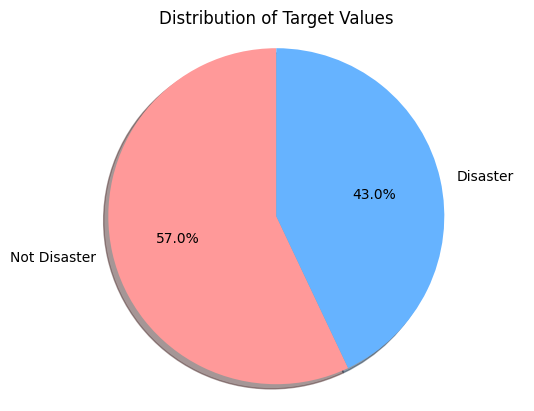

In [440]:
# Distribution of target values
target_counts = train.target.value_counts()
print(target_counts)

# Create a figure with a single subplot
fig, ax = plt.subplots()

# Colors and explode settings for better visualization
colors = ['#ff9999','#66b3ff']

# Pie chart for target values
ax.pie(target_counts, labels=['Not Disaster', 'Disaster'], colors=colors, autopct='%1.1f%%', startangle=90, shadow=True)
ax.set_title('Distribution of Target Values')
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Display the plot
plt.show()

Now we will try to understand which kind of keywords are present in the data. All tweets are filtered by some specific identifying keyword, e.g. "bomb" or "earthquake". Let us now try to understand the distribution of these keywords in the data. 

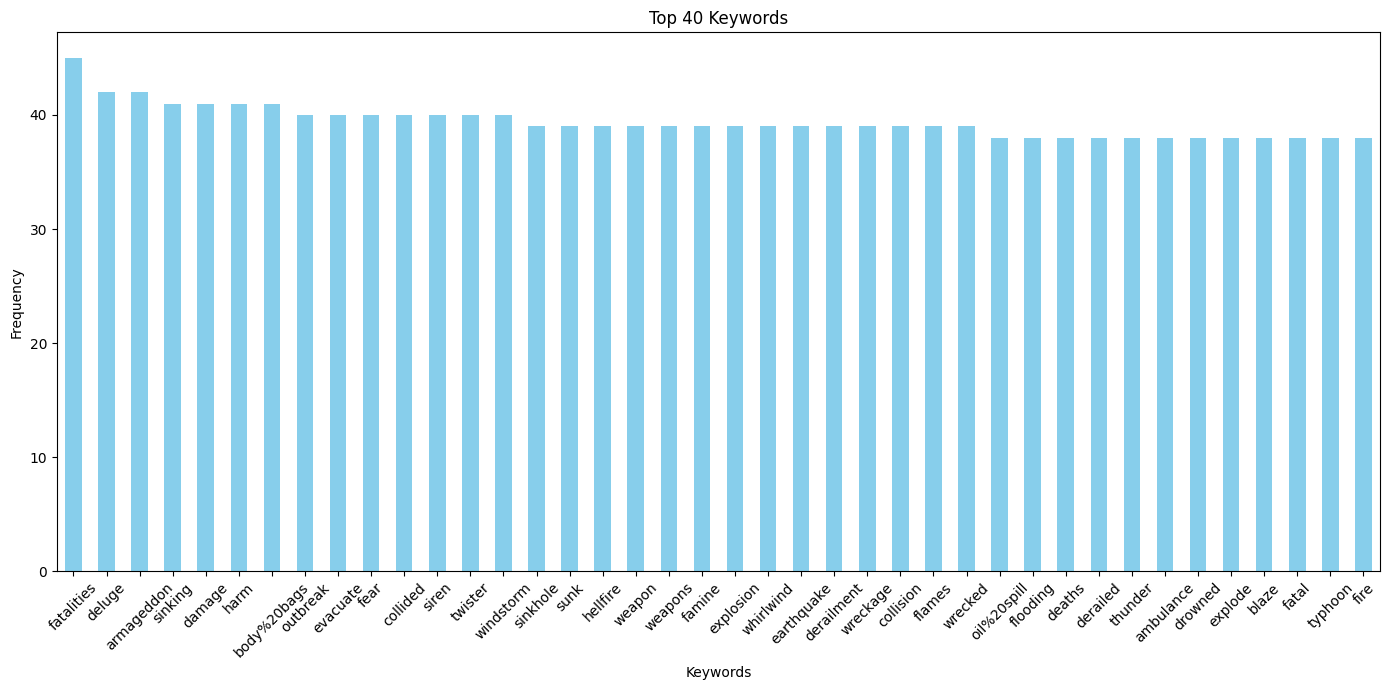

In [441]:
# Create a bar plot of the top 20 keywords
train['keyword'].value_counts().head(40).plot(kind='bar', figsize=(14, 7), color='skyblue')
plt.title('Top 40 Keywords')
plt.xlabel('Keywords')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Now let us move on to the location

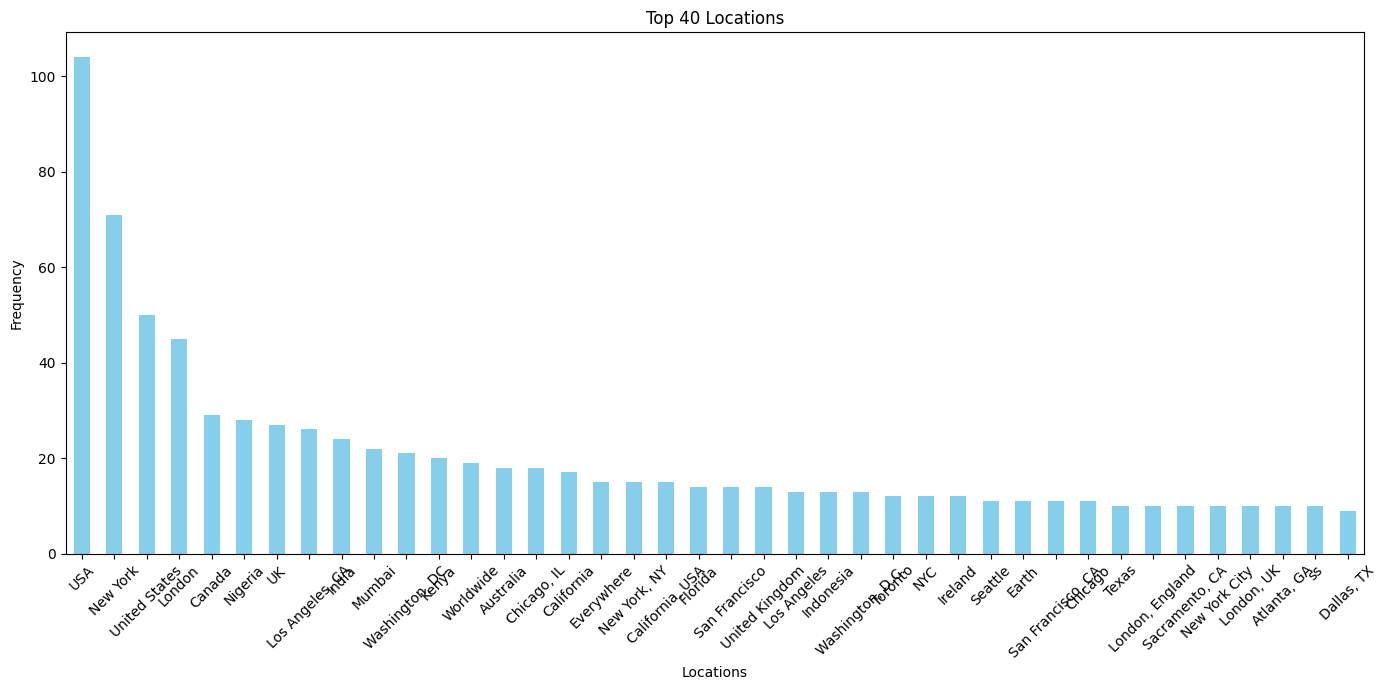

In [442]:
# Create a bar plot of the top 40 locations
train['location'].value_counts().head(40).plot(kind='bar', figsize=(14, 7), color='skyblue')
plt.title('Top 40 Locations')
plt.xlabel('Locations')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

As we can see, there are some duplicates. "USA" should be the same as "United States" and "New York, NY" should be the same as "New York". Furthermore, the locations "Earth", "Everywhere" and "World" are rather useless. Let us clean this up.

In [443]:
# Fixing duplicate locations

# Replace New York, NY and New York City with New York
train['location'] = train['location'].replace('New York, NY', 'New York')
train['location'] = train['location'].replace('New York City', 'New York')
train['location'] = train['location'].replace('NYC', 'New York')


# Replace United States with USA
train['location'] = train['location'].replace('United States', 'USA')
train['location'] = train['location'].replace('US', 'USA')

# Replace United Kingdom with UK
train['location'] = train['location'].replace('United Kingdom', 'UK')

# Replace Los Angeles, CA with Los Angeles
train['location'] = train['location'].replace('Los Angeles, CA', 'Los Angeles')

# Replace Washington, D.C. with Washington
train['location'] = train['location'].replace('Washington, DC', 'Washington')

# Replace San Francisco, CA with San Francisco
train['location'] = train['location'].replace('San Francisco, CA', 'San Francisco')

# Replace California, USA with California
train['location'] = train['location'].replace('California, USA', 'California')

# Replace Chicago, IL with Chicago
train['location'] = train['location'].replace('Chicago, IL', 'Chicago')

# Replace London, England with London
train['location'] = train['location'].replace('London, England', 'London')
train['location'] = train['location'].replace('London, UK', 'London')

# Replace locations "Earth", "World", "Everywhere" with NaN
train['location'] = train['location'].replace('Earth', np.nan)
train['location'] = train['location'].replace('World', np.nan)
train['location'] = train['location'].replace('Everywhere', np.nan)
train['location'] = train['location'].replace('Worldwide', np.nan)



While I have now removed some duplicates, it is difficult to clean the data further, since it is a manual process. There are some locations that are not useful, such as "Earth" and "World" and the labelling is not consistent. Some are states and some are cities, others are countries. This is a problem that is difficult to solve, but we will leave it as is for now. If I see, that it seriously impacts the performance later on, I will fix this. 

Let us now analyse the content of the tweets themselves

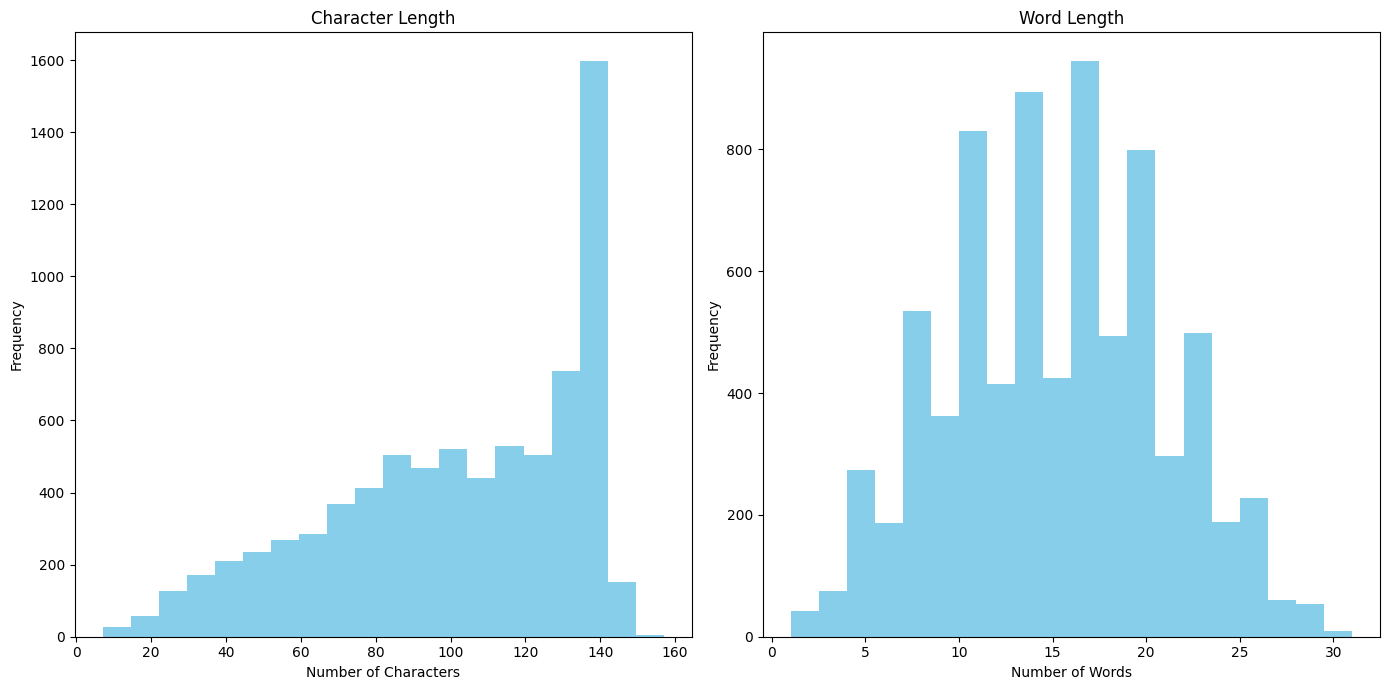

In [444]:
# Make two bar plots of the character and the word length of the tweets
# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Character length plot
train['text'].str.len().plot(kind='hist', bins=20, color='skyblue', ax=ax[0])
ax[0].set_title('Character Length')
ax[0].set_xlabel('Number of Characters')
ax[0].set_ylabel('Frequency')

# Word length plot
train['text'].str.split().map(lambda x: len(x)).plot(kind='hist', bins=20, color='skyblue', ax=ax[1])
ax[1].set_title('Word Length')
ax[1].set_xlabel('Number of Words')
ax[1].set_ylabel('Frequency')

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

Now it is helpful to understand whether these numbers differ between the two classes.

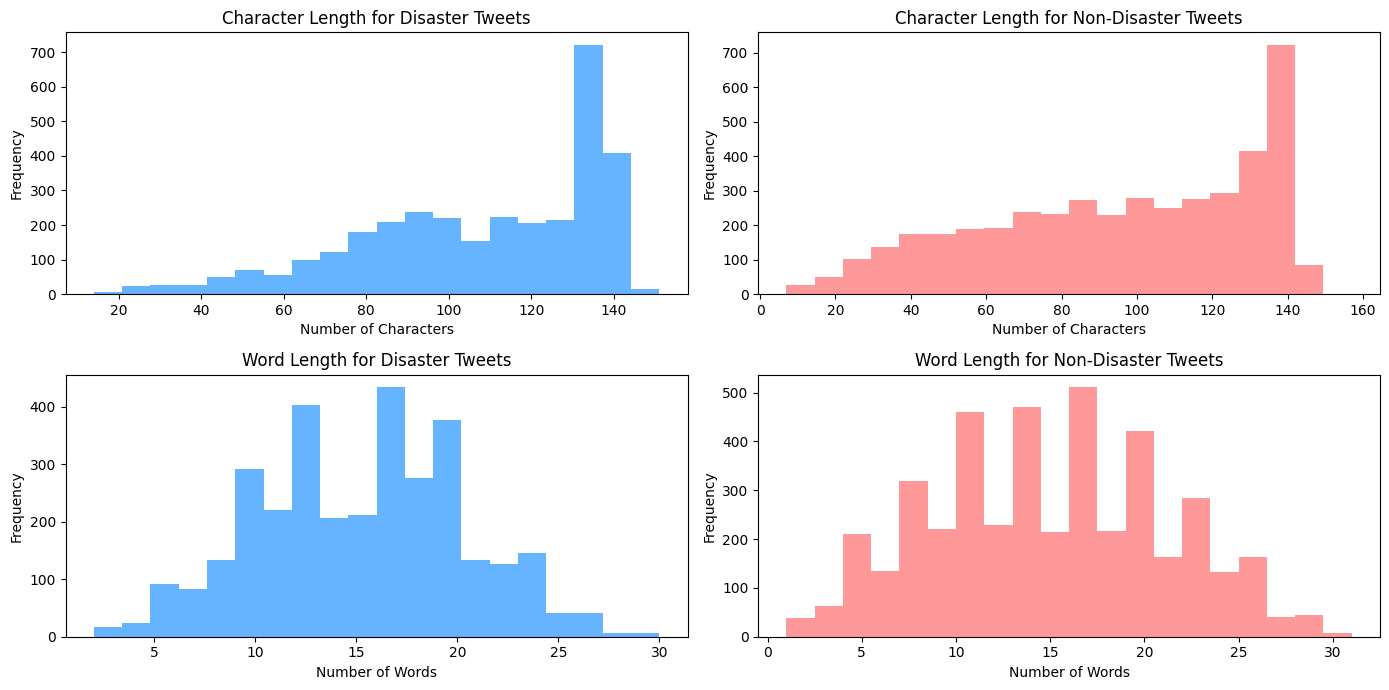

In [445]:
fig, ax = plt.subplots(2, 2, figsize=(14, 7))

# Character length plot for disaster tweets
disaster_char_lengths = train[train['target'] == 1]['text'].str.len()
disaster_char_lengths.plot(kind='hist', bins=20, color='#66b3ff', ax=ax[0][0])
ax[0][0].set_title('Character Length for Disaster Tweets')
ax[0][0].set_xlabel('Number of Characters')
ax[0][0].set_ylabel('Frequency')

# Character length plot for non-disaster tweets
nondisaster_char_lengths = train[train['target'] == 0]['text'].str.len()
nondisaster_char_lengths.plot(kind='hist', bins=20, color='#ff9999', ax=ax[0][1])
ax[0][1].set_title('Character Length for Non-Disaster Tweets')
ax[0][1].set_xlabel('Number of Characters')
ax[0][1].set_ylabel('Frequency')

# Word length plot for disaster tweets
disaster_word_lengths = train[train['target'] == 1]['text'].str.split().map(len)
disaster_word_lengths.plot(kind='hist', bins=20, color='#66b3ff', ax=ax[1][0])
ax[1][0].set_title('Word Length for Disaster Tweets')
ax[1][0].set_xlabel('Number of Words')
ax[1][0].set_ylabel('Frequency')

# Word length plot for non-disaster tweets
nondisaster_word_lengths = train[train['target'] == 0]['text'].str.split().map(len)
nondisaster_word_lengths.plot(kind='hist', bins=20, color='#ff9999', ax=ax[1][1])
ax[1][1].set_title('Word Length for Non-Disaster Tweets')
ax[1][1].set_xlabel('Number of Words')
ax[1][1].set_ylabel('Frequency')

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()


We see that the distributions do not vary significantly between the two classes.

### 1.4 Data Cleaning

Let us first fill all empty values:

In [446]:
train['location'].fillna('Unknown', inplace=True)
train['keyword'].fillna('Unknown', inplace=True)
train['text'].fillna('', inplace=True)  # Assuming no critical info is lost


Since these tweets stem from Twitter, they contain a lot of noise. We will now clean the data by removing URLs, HTML tags, emojis, special characters and stopwords.

Lets begin by removing punctuation and special characters.

In [447]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [448]:
# Creating a function to remove punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

# Apply the function to the text column
train['clean_text'] = train['text'].apply(remove_punctuation)

Moving on to removing URLs

In [449]:
# Removing URLs
def remove_URL(text):
    url = re.compile(r'https?://\S+|www\.\S+')
    return url.sub(r'',text)

train["clean_text"] = train["clean_text"].apply(remove_URL)

In [450]:
# Removing HTML tags
def remove_html(text):
    clean = re.compile('<.*?>')
    # Use sub() to replace HTML tags with an empty string
    return re.sub(clean, '', text)

train["clean_text"] = train["clean_text"].apply(remove_html)

In [451]:
train['clean_text'] = train['clean_text'].str.lower()

Let us further analyse the data by removing stopwords. Before we do this, let us understand how stopwords are distributed in the data. 

In [452]:
# Removing stopwords
from nltk.corpus import stopwords
nltk.download('stopwords')

stop = set(stopwords.words('english'))

def remove_stopwords(text):
    text = [word for word in text.split() if word.lower() not in stop]
    return " ".join(text)

train['clean_text'] = train['clean_text'].apply(remove_stopwords)


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/casparlehmkuhler/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [453]:
# Stemming 
from nltk.stem.porter import PorterStemmer
stemmer = PorterStemmer()

def stemming(text):
    text = [stemmer.stem(word) for word in text.split()]
    return " ".join(text)

train['clean_text'] = train['clean_text'].apply(stemming)

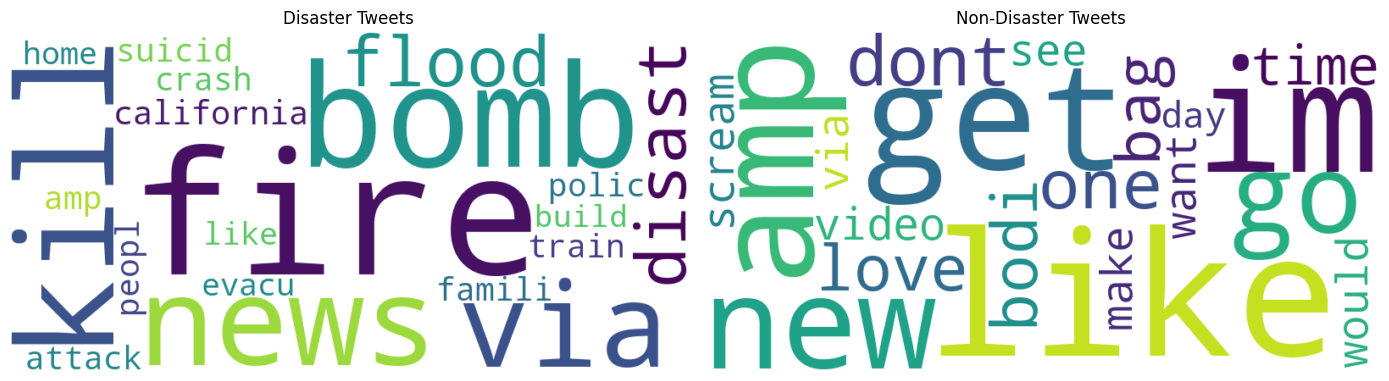

In [454]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Assume 'train' DataFrame and 'clean_text' processing is correctly set up
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Get the most common words in disaster tweets
disaster_words = train[train['target'] == 1]['clean_text'].str.split().explode()
disaster_common_words = Counter(disaster_words).most_common(20)

# Get the most common words in non-disaster tweets
nondisaster_words = train[train['target'] == 0]['clean_text'].str.split().explode()
nondisaster_common_words = Counter(nondisaster_words).most_common(20)

# Create a word cloud for disaster tweets
disaster_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(disaster_common_words))
ax[0].imshow(disaster_wordcloud, interpolation='bilinear')
ax[0].set_title('Disaster Tweets')
ax[0].axis('off')  # Hide axes for cleaner presentation

# Create a word cloud for non-disaster tweets
nondisaster_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(nondisaster_common_words))
ax[1].imshow(nondisaster_wordcloud, interpolation='bilinear')
ax[1].set_title('Non-Disaster Tweets')
ax[1].axis('off')  # Hide axes for cleaner presentation

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()


There are still unnecessary words such as like "amp" and "gt" in the data. Let us remove these as well.

In [455]:
# Removing common words

# Create a list of common words
common_words = ['amp', 'like', 'get', 'one', 'new', 'via', 'would', 'video', 'know', 'us', 'back', 'watch', 'good', '2', 'first', 'last', 'going',   'still',
                'see', 'think', 'made', 'even', 'look', 'many', 'may', 'next',
                'great', 'well', 'take', 'year', 'say', 'want', 'best', 'come', 'big', 'use', 'week', 'ever', 'let', 'show', 'find',"got",'im']

# Create a function to remove common words
def remove_common_words(text):
    text = [word for word in text.split() if word not in common_words]
    return " ".join(text)

train['clean_text'] = train['clean_text'].apply(remove_common_words)

In [456]:
train.head(10)

,keyword,location,text,target,clean_text
id,,,,,
1,Unknown,Unknown,Our Deeds are the Reason of this #earthquake M...,1,deed reason earthquak allah forgiv
4,Unknown,Unknown,Forest fire near La Ronge Sask. Canada,1,forest fire near la rong sask canada
5,Unknown,Unknown,All residents asked to 'shelter in place' are ...,1,resid ask shelter place notifi offic evacu she...
6,Unknown,Unknown,"13,000 people receive #wildfires evacuation or...",1,13000 peopl receiv wildfir evacu order california
7,Unknown,Unknown,Just got sent this photo from Ruby #Alaska as ...,1,sent photo rubi alaska smoke wildfir pour school
8,Unknown,Unknown,#RockyFire Update => California Hwy. 20 closed...,1,rockyfir updat california hwi 20 close direct ...
10,Unknown,Unknown,#flood #disaster Heavy rain causes flash flood...,1,flood disast heavi rain caus flash flood stree...
13,Unknown,Unknown,I'm on top of the hill and I can see a fire in...,1,top hill fire wood
14,Unknown,Unknown,There's an emergency evacuation happening now ...,1,there emerg evacu happen build across street


Let us now tokenize the data.

In [457]:
# Tokenization
from nltk.tokenize import word_tokenize
nltk.download('punkt')

def tokenization(text):
    text = re.split('\W+', text)
    return text


train['tokenized_text'] = train['clean_text'].apply(tokenization)

train.head()

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/casparlehmkuhler/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,keyword,location,text,target,clean_text,tokenized_text
id,,,,,,
1,Unknown,Unknown,Our Deeds are the Reason of this #earthquake M...,1,deed reason earthquak allah forgiv,"[deed, reason, earthquak, allah, forgiv]"
4,Unknown,Unknown,Forest fire near La Ronge Sask. Canada,1,forest fire near la rong sask canada,"[forest, fire, near, la, rong, sask, canada]"
5,Unknown,Unknown,All residents asked to 'shelter in place' are ...,1,resid ask shelter place notifi offic evacu she...,"[resid, ask, shelter, place, notifi, offic, ev..."
6,Unknown,Unknown,"13,000 people receive #wildfires evacuation or...",1,13000 peopl receiv wildfir evacu order california,"[13000, peopl, receiv, wildfir, evacu, order, ..."
7,Unknown,Unknown,Just got sent this photo from Ruby #Alaska as ...,1,sent photo rubi alaska smoke wildfir pour school,"[sent, photo, rubi, alaska, smoke, wildfir, po..."


### 1.5 Data Preprocessing 

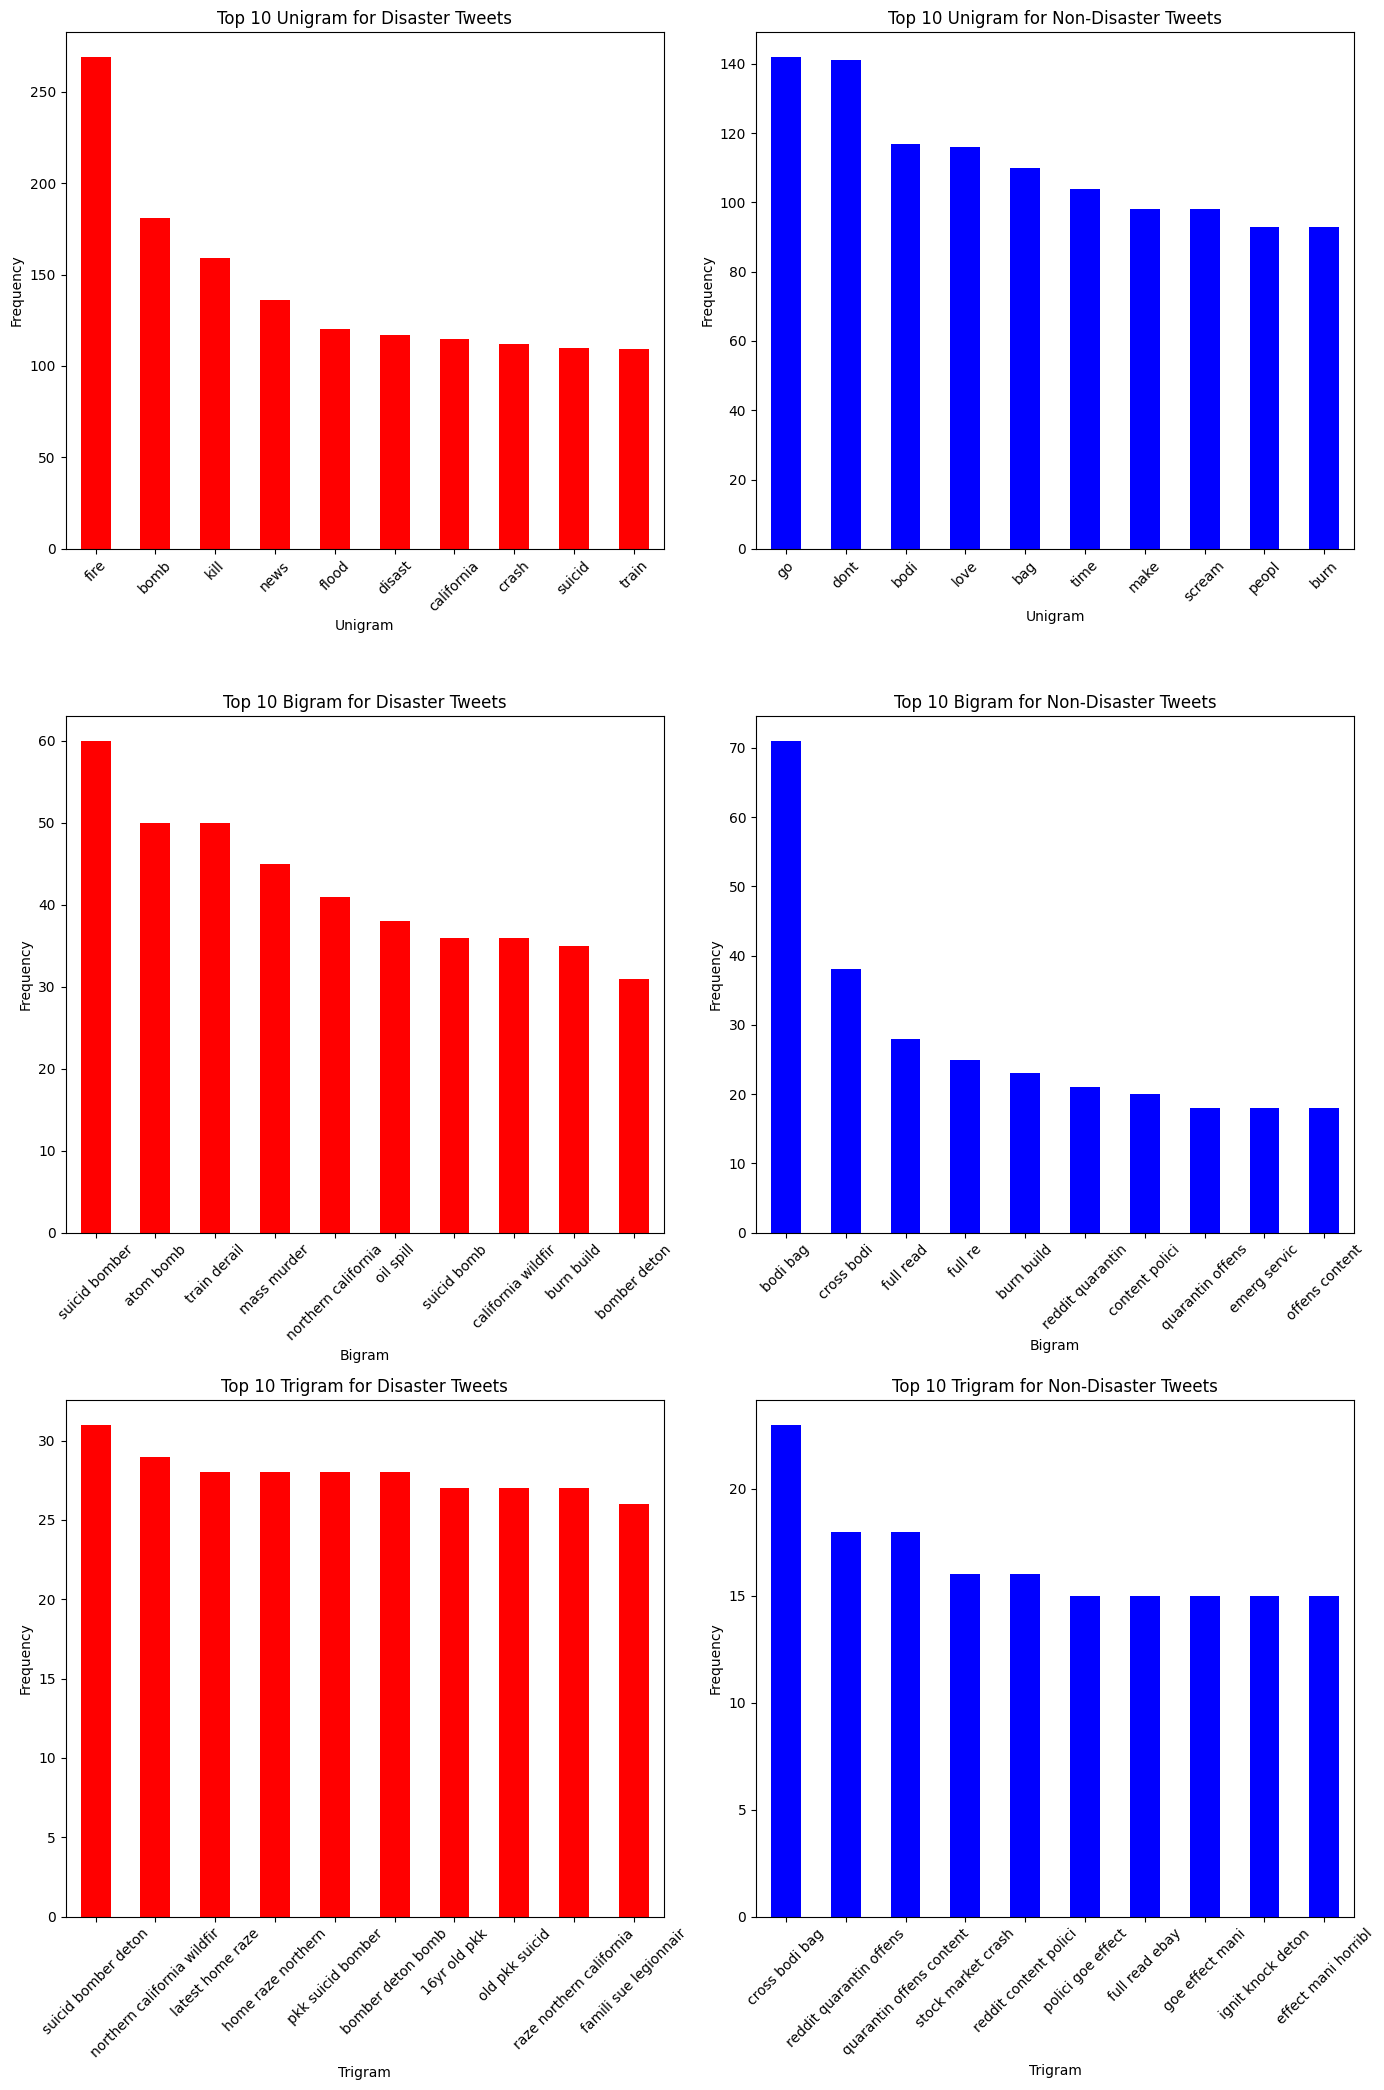

In [458]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'train' is your DataFrame and 'clean_text' has been properly cleaned/preprocessed
fig, ax = plt.subplots(3, 2, figsize=(14, 21))  # 3 rows for uni-, bi-, trigrams, and 2 columns for each class

# Definitions for ngram ranges
ngram_definitions = {
    'Unigram': (1, 1),
    'Bigram': (2, 2),
    'Trigram': (3, 3)
}

# Separate disaster and non-disaster data
disaster_texts = train[train['target'] == 1]['clean_text']
non_disaster_texts = train[train['target'] == 0]['clean_text']

# Process each n-gram type
for index, (ngram_name, ngram_range) in enumerate(ngram_definitions.items()):
    # Setup vectorizers for disaster and non-disaster
    vectorizer_disaster = CountVectorizer(ngram_range=ngram_range)
    vectorizer_non_disaster = CountVectorizer(ngram_range=ngram_range)
    
    # Transform data
    X_disaster = vectorizer_disaster.fit_transform(disaster_texts)
    X_non_disaster = vectorizer_non_disaster.fit_transform(non_disaster_texts)
    
    # Get features and sum up counts
    features_disaster = vectorizer_disaster.get_feature_names_out()
    sums_disaster = X_disaster.sum(axis=0)
    features_non_disaster = vectorizer_non_disaster.get_feature_names_out()
    sums_non_disaster = X_non_disaster.sum(axis=0)
    
    # Prepare data for plotting
    data_disaster = [(term, sums_disaster[0, idx]) for idx, term in enumerate(features_disaster)]
    data_non_disaster = [(term, sums_non_disaster[0, idx]) for idx, term in enumerate(features_non_disaster)]
    
    ranking_disaster = pd.DataFrame(data_disaster, columns=['term', 'rank']).sort_values('rank', ascending=False)
    ranking_non_disaster = pd.DataFrame(data_non_disaster, columns=['term', 'rank']).sort_values('rank', ascending=False)
    
    # Top 10 n-grams for disaster and non-disaster
    top_n_disaster = ranking_disaster.head(10)
    top_n_non_disaster = ranking_non_disaster.head(10)
    
    # Plot for disaster tweets
    top_n_disaster.plot(kind='bar', x='term', y='rank', ax=ax[index][0], color='red', title=f'Top 10 {ngram_name} for Disaster Tweets')
    ax[index][0].set_xlabel(f'{ngram_name}')
    ax[index][0].set_ylabel('Frequency')
    ax[index][0].set_xticklabels(top_n_disaster['term'], rotation=45)
    ax[index][0].legend().set_visible(False)
    
    # Plot for non-disaster tweets
    top_n_non_disaster.plot(kind='bar', x='term', y='rank', ax=ax[index][1], color='blue', title=f'Top 10 {ngram_name} for Non-Disaster Tweets')
    ax[index][1].set_xlabel(f'{ngram_name}')
    ax[index][1].set_ylabel('Frequency')
    ax[index][1].set_xticklabels(top_n_non_disaster['term'], rotation=45)
    ax[index][1].legend().set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()

plt.show()





Let us now encode the data. We will use the TF-IDF vectorizer for this purpose.

In [459]:
# TF-IDF Vectorization for the "clean text" column

# Create a TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()
# Fit and transform the data
X_text = tfidf_vectorizer.fit_transform(train['clean_text'])

# Combining location and keyword for one-hot encoding
encoder = OneHotEncoder(handle_unknown='ignore')
X_categorical = encoder.fit_transform(train[['location', 'keyword']])




## 2. Model Selection and Training

### 2.1 Base Model (Logistic Regression)

In [460]:
X_combined = hstack([X_text, X_categorical])
y = train['target']

X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

# Create a Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7787261982928431
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       874
           1       0.76      0.70      0.73       649

    accuracy                           0.78      1523
   macro avg       0.78      0.77      0.77      1523
weighted avg       0.78      0.78      0.78      1523



### 2.2 Explicit Sentiment Analysis using BERT

In [461]:
# Loading the tokenizer and the model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased')


# model = BertForSequenceClassification.from_pretrained(
#   'bert-base-uncased',  # Use the 12-layer BERT model, with an uncased vocab.
#    num_labels = 2,  # The number of output labels. 2 for binary classification.
#    output_attentions = False,  # Whether the model returns attentions weights.
#    output_hidden_states = False,  # Whether the model returns all hidden-states.
#)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [462]:
# Tokenize all of the sentences and map the tokens to their word IDs.
input_ids = []
attention_masks = []

# For every sentence...
for sent in train['clean_text']:
    encoded_dict = tokenizer.encode_plus(
                  sent,                      
                  add_special_tokens = True, 
                  max_length = 128,  # Reduced from 512
                  pad_to_max_length = True,
                  return_attention_mask = True,   
                  return_tensors = 'pt',
               )
    
    # Add the encoded sentence to the list.    
    input_ids.append(encoded_dict['input_ids'])
    
    # And its attention mask (simply differentiates padding from non-padding).
    attention_masks.append(encoded_dict['attention_mask'])

# Convert the lists into tensors.
input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)
labels = torch.tensor(train['target'].values)

# Set up the DataLoader for our training set
dataset = TensorDataset(input_ids, attention_masks, labels)
batch_size = 32
dataloader = DataLoader(
            dataset,  # The training samples.
            sampler = RandomSampler(dataset), # Select batches randomly
            batch_size = batch_size # Trains with this batch size.
)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


In [464]:
# Set the optimizer
optimizer = AdamW(model.parameters(),
                  lr = 2e-5, # args.learning_rate
                  eps = 1e-8 # args.adam_epsilon
                )

# Number of training epochs (authors recommend between 2 and 4)
epochs = 4

# Total number of training steps is [number of batches] x [number of epochs].
total_steps = len(dataloader) * epochs

# Create the learning rate scheduler.
scheduler = get_linear_schedule_with_warmup(optimizer, 
                                            num_warmup_steps = 0, # Default value
                                            num_training_steps = total_steps)


In [466]:
device = torch.device("cpu")

# Put the model in training mode.
model.train()

# For each epoch...
for epoch in range(0, epochs):
    print('======== Epoch {:} / {:} ========'.format(epoch + 1, epochs))
    print('Training...')

    # Reset the total loss for this epoch.
    total_loss = 0

    # Create a progress bar for the training batches
    progress_bar = tqdm(dataloader, desc="Batch", leave=False)

    # For each batch of training data...
    for step, batch in enumerate(dataloader):
        # Progress update every 40 batches.
        if step % 40 == 0 and not step == 0:
            print('  Batch {:>5,}  of  {:>5,}. '.format(step, len(dataloader)))

        # Unpack this training batch from our dataloader. 
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        # Clear any previously calculated gradients before performing a backward pass.
        model.zero_grad()        

        # Perform a forward pass (evaluate the model on this training batch).
        outputs = model(b_input_ids, 
                        attention_mask=b_input_mask, 
                        labels=b_labels)
        
        loss = outputs.loss
        total_loss += loss.item()

        # Perform a backward pass to calculate the gradients.
        loss.backward()

        # Clip the norm of the tensors to 1.0.
        # This is to help prevent the "exploding gradients" problem.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Update parameters and take a step using the computed gradient.
        optimizer.step()

        # Update the learning rate.
        scheduler.step()
            
        
        progress_bar.set_description(f"Epoch {epoch + 1} Step {step} Loss {loss.item():.2f}")


    # Calculate the average loss over the training data.
    avg_train_loss = total_loss / len(dataloader)            
    
    print("  Average training loss: {0:.2f}".format(avg_train_loss))

======== Epoch 1 / 4 ========
Training...


Epoch 1 Step 39 Loss 0.57:   0%|          | 0/238 [02:29<?, ?it/s]

  Batch    40  of    238. 


Epoch 1 Step 79 Loss 0.62:   0%|          | 0/238 [04:39<?, ?it/s]

  Batch    80  of    238. 


Epoch 1 Step 119 Loss 0.43:   0%|          | 0/238 [06:48<?, ?it/s]

  Batch   120  of    238. 


Epoch 1 Step 127 Loss 0.43:   0%|          | 0/238 [07:15<?, ?it/s]